In [1]:
# Import statements
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import acf
from matplotlib import colormaps
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from scipy.optimize import linear_sum_assignment

In [42]:
cases_plot = pd.read_csv('cases_total.csv')
cases_plot['date'] = pd.to_datetime(cases_plot['date'])
cases_plot.set_index('date',inplace=True)
counts = cases_plot[cases_plot['area_name']=='Maidstone']

In [43]:
wide_data_incidence = pd.read_csv('wide_incidence_full.csv',header=[0,1], index_col=0)
wide_data_total = pd.read_csv('wide_total_full.csv',header=[0,1], index_col=0)
npis = pd.read_csv('ltla_to_nhs.csv')
weekly_counts_total = pd.read_csv('weekly_total_full.csv')
test = wide_data_incidence.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_incidence = test
test = wide_data_total.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_total = test

In [44]:
import pickle        
with open('ltla_transitions.pkl', 'rb') as f:
    ltla_transitions = pickle.load(f)

In [13]:
def is_constant(series):
    return np.all(series == series[0])

def is_low_variance(series, threshold=1e-5):
    return np.var(series) < threshold

def rolling_tests_multivariate(ts, window=50, alpha=0.05):
    n_variables = ts.shape[1]
    sigma_results = []
    
    for i in range(window, len(ts)):
        sigma_flags = []

        for var in range(n_variables):
            window_data = ts[i-window:i, var]
            
            if is_constant(window_data):
                sigma_flags.append(False)
                continue            

            window_std = np.std(window_data)
            mean_std = np.mean([np.std(ts[max(0, j-window):j, var]) for j in range(i-window, i)])
            sigma_flags.append(window_std > 2 * mean_std)

        sigma_results.append(np.array(sigma_flags))

    return np.array(sigma_results)

def cossine_sim(ts):
    cos_sims = [0]

    for i in range(1, len(ts)):
        if np.linalg.norm(ts[i-1]) == 0:
            cos_sims.append(np.nan)
        else:
            dot_product = np.abs(np.vdot(ts[i-1], ts[i]))
            norm_product = np.linalg.norm(ts[i-1]) * np.linalg.norm(ts[i])
            cos_sim = dot_product / norm_product
            cos_sims.append(cos_sim)

    return np.array(cos_sims)

def angle_displacement(ts):
    angle_displacements = [0]

    for i in range(1, len(ts)):
        if np.linalg.norm(ts[i-1]) == 0:
            angle_displacements.append(np.nan)
        else:
            dot_product = np.dot(ts[i-1], ts[i])
            norm_product = np.linalg.norm(ts[i-1]) * np.linalg.norm(ts[i])
            cos_sim = dot_product / norm_product
            angle = np.arccos(np.clip(cos_sim, -1.0, 1.0))
            angle_displacements.append(angle)

    return np.array(angle_displacements)

def cusum(data, threshold=3, drift=0, noise_std=0.01):
    pos_cusum = np.zeros(len(data))
    signal_indices = np.zeros(len(data))
    for i in range(1, len(data)):
        pos_cusum[i] = max(0, pos_cusum[i-1] + data[i] - drift-noise_std)
        if pos_cusum[i] > threshold * noise_std:
            pos_cusum[i] = 0  # Reset after signal
            signal_indices[i] = 1
    return signal_indices

In [23]:
def plot_results_multivariate(ts, evectors_100, evectors_60, change_points, window, title, figtitle, std = (0.01,0.03)):
    sigma_results = rolling_tests_multivariate(evectors_100, window)
    ang_100_raw = angle_displacement(evectors_100)
    ang_100_flags = cusum(ang_100_raw, noise_std=std[0])[window:].astype(bool)

    n_variables = evectors_100.shape[1]

    fig, axes = plt.subplots(1, 2, figsize=(24, 8), sharex=True)

    tests = [("2-Sigma", sigma_results), ("Angular Displacement", ang_100_flags)]
    colors = ['red', 'blue']
    
    ax = axes[0]
    ax.plot(ts['date'],ts['value'],'.',color='#2A1E5C')
    ax.plot(ts['date'],ts['rolling'],color='#D62828')
    ax = ax.twinx()
    for i, ((test_name, results), color) in enumerate(zip(tests, colors)):
        if test_name == "2-Sigma":
            for var in range(n_variables):
                ax.scatter(ts['date'][window:][results[:, var]], np.ones(np.sum(results[:, var])) * (i+1), 
                           color=color, alpha=0.5, label=f'{test_name}' if var == 0 else "")
        else:
            ax.scatter(ts['date'][window:][ang_100_flags], np.ones(np.sum(ang_100_flags)) * (i+1), 
                       color=color, alpha=0.7, label=f'{test_name}')

        for cp in change_points:
            ax.axvline(cp, color='black', linestyle='--', alpha=0.7, ymin=-6, ymax = 6)
    ax.set_ylim((-6,6))
    ax.set_title(f"100 days - {title}")
    ax.legend()

    sigma_results = rolling_tests_multivariate(evectors_60, window)
    ang_60_raw = angle_displacement(evectors_60)
    ang_60_flags = cusum(ang_60_raw, noise_std=std[1])[window:].astype(bool)

    tests = [("2-Sigma", sigma_results), ("Angular Displacement", ang_60_flags)]

    ax = axes[1]
    ax.plot(ts['date'],ts['value'],'.',color='#2A1E5C')
    ax.plot(ts['date'],ts['rolling'],color='#D62828')
    ax = ax.twinx()
    for i, ((test_name, results), color) in enumerate(zip(tests, colors)):
        if test_name == "2-Sigma":
            for var in range(n_variables):
                ax.scatter(ts['date'][window:][results[:, var]], np.ones(np.sum(results[:, var])) * (i+1), 
                           color=color, alpha=0.5, label=f'{test_name}' if var == 0 else "")
        else:
            ax.scatter(ts['date'][window:][ang_60_flags], np.ones(np.sum(ang_60_flags)) * (i+1), 
                       color=color, alpha=0.7, label=f'{test_name}')

        for cp in change_points:
            ax.axvline(cp, color='black', linestyle='--', alpha=0.7, ymin=-6, ymax = 6)
    ax.set_ylim((-6,6))
    ax.set_title(f"60 days - {title}")
    ax.legend()

    plt.xlabel("Time")
    plt.savefig(f"Figures/{figtitle}.pdf",dpi=2400,bbox_inches='tight')
    plt.show()

## Maidstone 10-year

In [45]:
wide_data_incidence = pd.read_csv('wide_incidence_10year_full.csv',header=[0,1], index_col=0)
wide_data_total = pd.read_csv('wide_total_10year_full.csv',header=[0,1], index_col=0)
npis = pd.read_csv('ltla_to_nhs.csv')
weekly_counts_total = pd.read_csv('weekly_total_10year_full.csv')
test = wide_data_incidence.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_incidence = test
test = wide_data_total.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_total = test

In [46]:
rolling = wide_data_incidence['Maidstone'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_var = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_evec = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_100_total[i] = eigenvalues[dominant_index]
        cov_100_var[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_100_evec[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_100_evec[i] = np.array(10*[0])
        cov_100_total[i] = np.nan
        cov_100_var[i] = np.nan


rolling = wide_data_incidence['Maidstone'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_var = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_evec = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_60_total[i] = eigenvalues[dominant_index]
        cov_60_var[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_60_evec[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_60_evec[i] = np.array(10*[0])
        cov_60_total[i] = np.nan
        cov_60_var[i] = np.nan

rolling = wide_data_total['Maidstone'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_var_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_evec_det = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_100_total_det[i] = eigenvalues[dominant_index]
        cov_100_var_det[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_100_evec_det[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_100_evec_det[i] = np.array(10*[0])
        cov_100_total_det[i] = np.nan
        cov_100_var_det[i] = np.nan

rolling = wide_data_total['Maidstone'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_var_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_evec_det = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_60_total_det[i] = eigenvalues[dominant_index]
        cov_60_var_det[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_60_evec_det[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_60_evec_det[i] = np.array(10*[0])
        cov_60_total_det[i] = np.nan
        cov_60_var_det[i] = np.nan

/tmp/ipykernel_306900/3842990401.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['value'].rolling(7).mean()


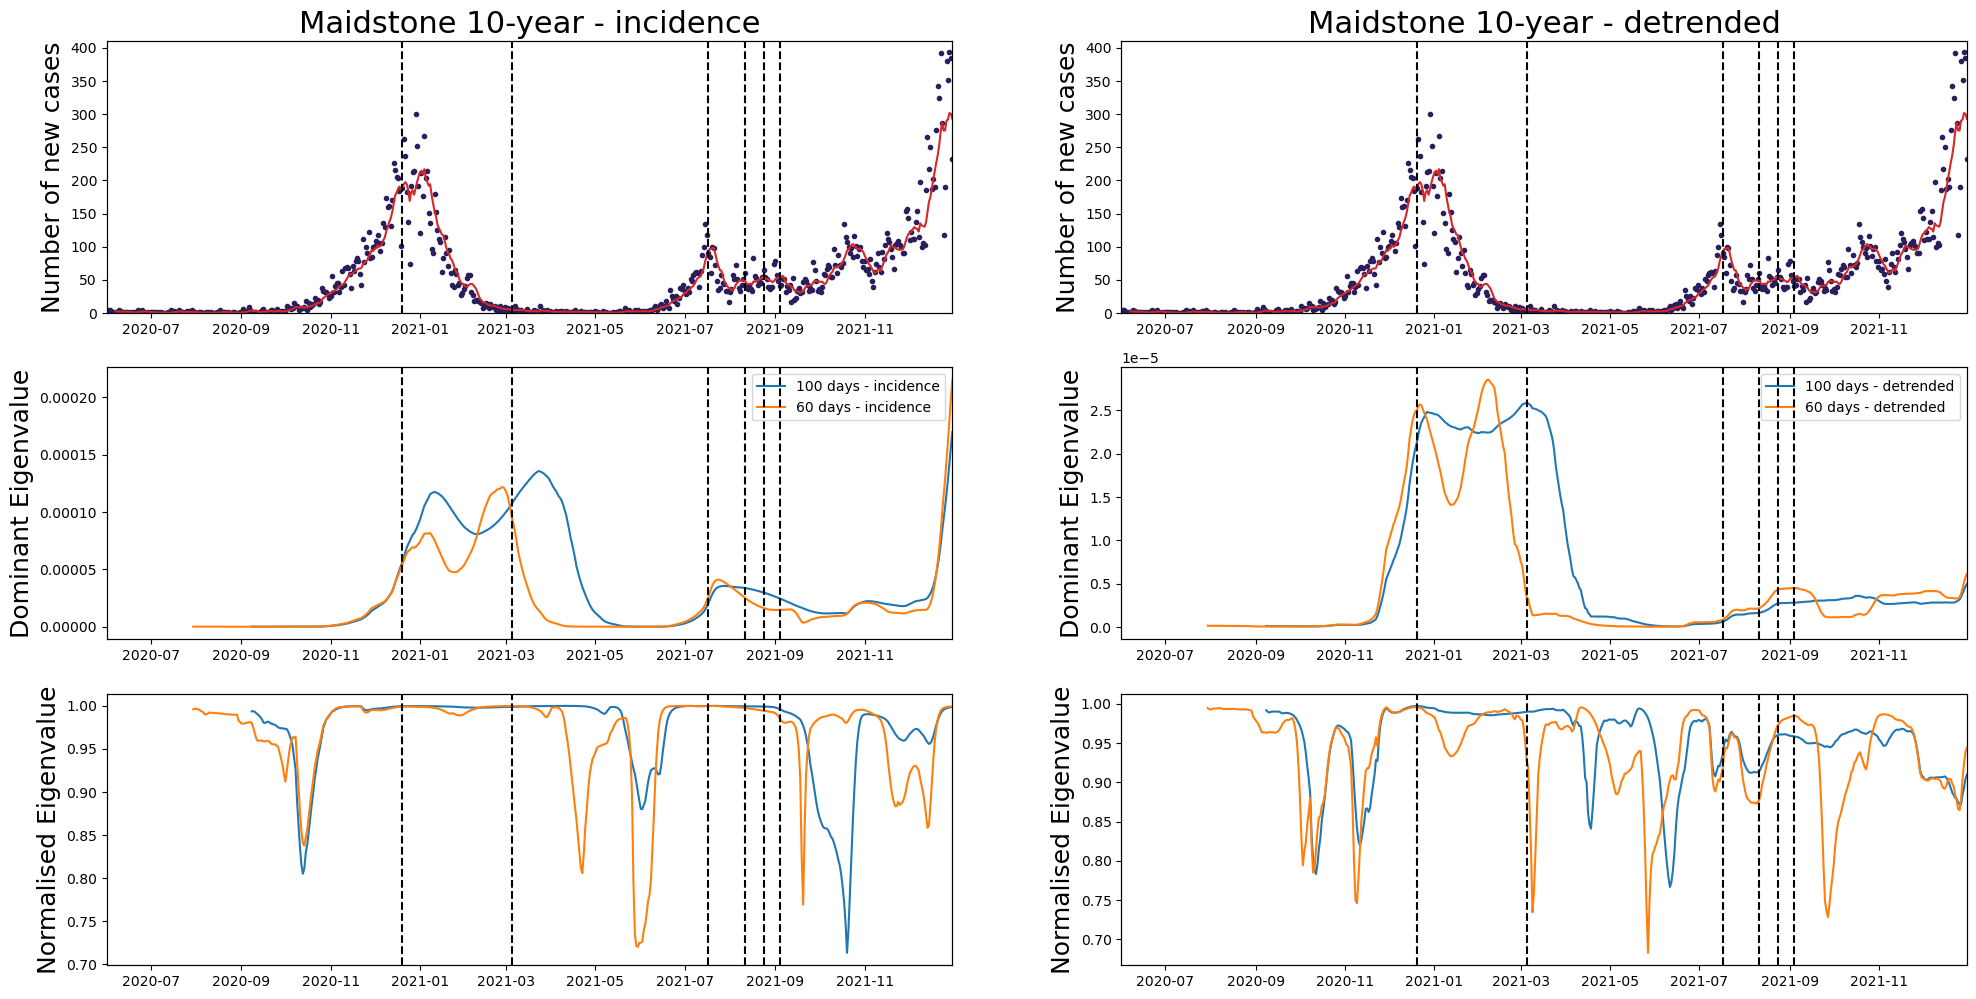

In [8]:
counts = cases_plot[cases_plot['area_name']=='Maidstone']
fig, axs = plt.subplots(nrows=3,ncols=2,figsize=(24,12))
counts['rolling'] = counts['value'].rolling(7).mean()
counts = counts.reset_index()
axs[0,0].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,0].set_ylim((0,410))
axs[0,0].set_title('Maidstone 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[1,0].plot(counts['date'],cov_100_total,label='100 days - incidence')
axs[2,0].plot(counts['date'],cov_100_var,label='100 days - incidence')
axs[1,0].plot(counts['date'],cov_60_total,label='60 days - incidence')
axs[2,0].plot(counts['date'],cov_60_var,label='60 days - incidence')
axs[1,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,0].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,0].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,0].legend()

axs[0,1].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,1].set_ylim((0,410))
axs[0,1].set_title('Maidstone 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[1,1].plot(counts['date'],cov_100_total_det,label='100 days - detrended')
axs[2,1].plot(counts['date'],cov_100_var_det,label='100 days - detrended')
axs[1,1].plot(counts['date'],cov_60_total_det,label='60 days - detrended')
axs[2,1].plot(counts['date'],cov_60_var_det,label='60 days - detrended')
axs[1,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,1].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,1].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,1].legend()
for i in range(3):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=ltla_transitions['Maidstone'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
plt.savefig("Figures/10yearevalues.pdf",dpi=2400,bbox_inches='tight')
plt.show()

/tmp/ipykernel_306900/3726519494.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['value'].rolling(7).mean()


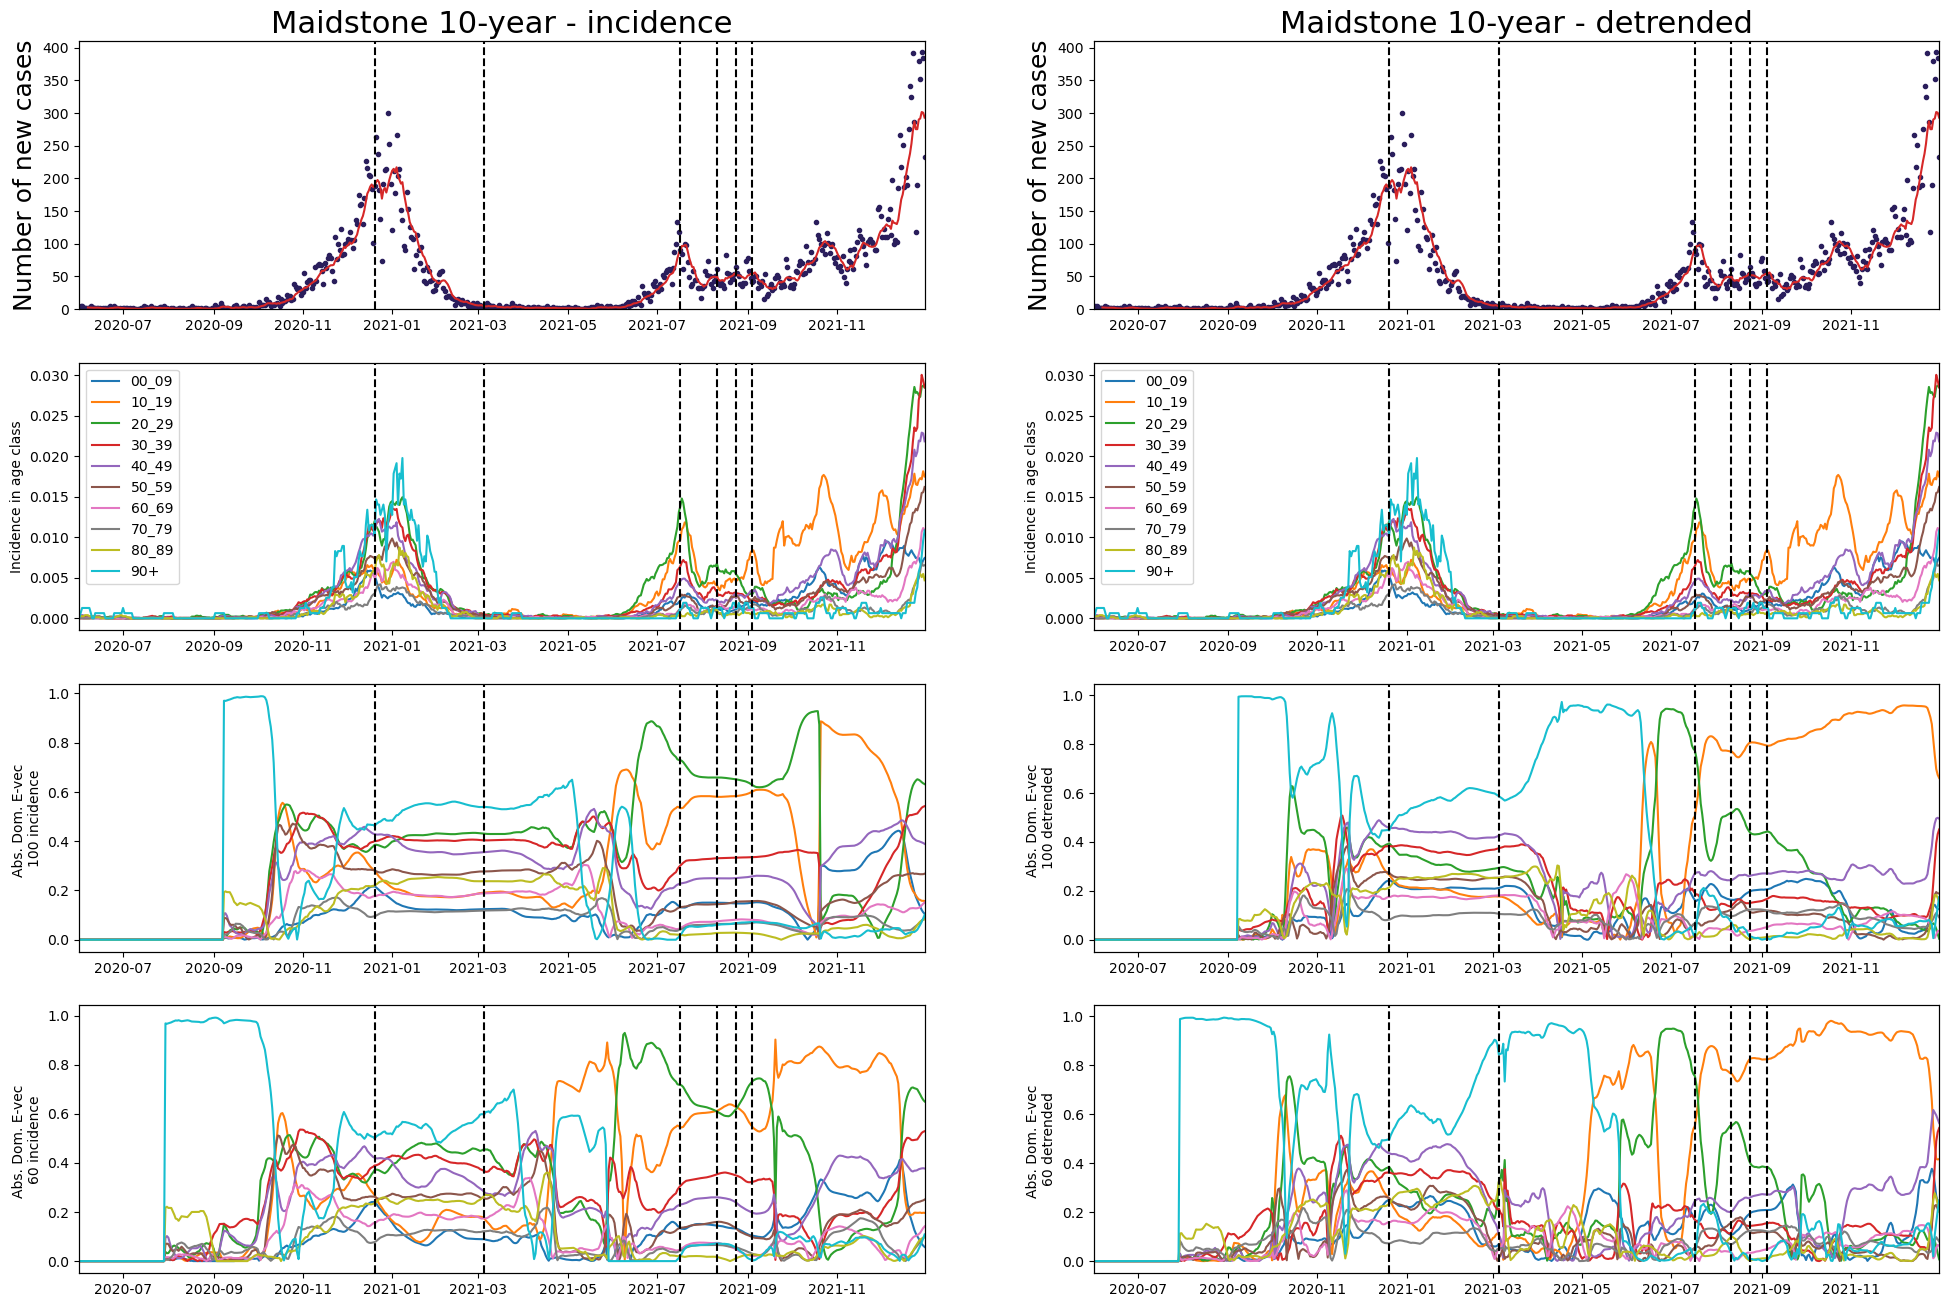

In [9]:
labs = ['00_09', '10_19', '20_29', '30_39', '40_49', '50_59', '60_69', '70_79','80_89', '90+']
counts = cases_plot[cases_plot['area_name']=='Maidstone']
cols = colormaps.get_cmap('tab10')(np.arange(10))
fig, axs = plt.subplots(nrows=4,ncols=2,figsize=(24,16))
counts['rolling'] = counts['value'].rolling(7).mean()
counts = counts.reset_index()
axs[0,0].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,0].set_ylim((0,410))
axs[0,0].set_title('Maidstone 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
for i in range(len(labs)):
    t = wide_data_incidence.Maidstone[labs[i]]
    axs[1,0].plot(counts['date'],t,label=labs[i])
axs[1,0].set_ylabel('Incidence in age class')
for i in range(len(cov_100_evec[0])):
    axs[2,0].plot(counts['date'],np.abs(cov_100_evec[:,i]))
axs[2,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,0].set_ylabel('Abs. Dom. E-vec \n100 incidence')
for i in range(len(cov_60_evec[0])):
    axs[3,0].plot(counts['date'],np.abs(cov_60_evec[:,i]))
axs[3,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[3,0].set_ylabel('Abs. Dom. E-vec \n60 incidence')
axs[1,0].legend()

axs[0,1].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,1].set_ylim((0,410))
axs[0,1].set_title('Maidstone 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
for i in range(len(labs)):
    t = wide_data_incidence.Maidstone[labs[i]]
    axs[1,1].plot(counts['date'],t,label=labs[i])
axs[1,1].set_ylabel('Incidence in age class')
for i in range(len(cov_100_evec_det[0])):
    axs[2,1].plot(counts['date'],np.abs(cov_100_evec_det[:,i]))
axs[2,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,1].set_ylabel('Abs. Dom. E-vec \n100 detrended')
for i in range(len(cov_60_evec_det[0])):
    axs[3,1].plot(counts['date'],np.abs(cov_60_evec_det[:,i]))
axs[3,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[3,1].set_ylabel('Abs. Dom. E-vec \n60 detrended')
axs[1,1].legend()
for i in range(4):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=ltla_transitions['Maidstone'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
plt.savefig("Figures/10yearevectors.pdf",dpi=2400,bbox_inches='tight')
plt.show()

In [10]:
rolling = wide_data_incidence['Maidstone'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_var = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_evec = np.zeros((len(cov.index.get_level_values(0).unique()),10))
cov_100_evecs = np.zeros((len(cov.index.get_level_values(0).unique()),10,10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_100_total[i] = eigenvalues[dominant_index]
        cov_100_var[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_100_evec[i, :] = eigenvectors[:, dominant_index].flatten()
        cov_100_evecs[i] = eigenvectors
    else:
        cov_100_evec[i] = np.array(10*[0])
        cov_100_total[i] = np.nan
        cov_100_var[i] = np.nan

/tmp/ipykernel_306900/842802289.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['value'].rolling(7).mean()


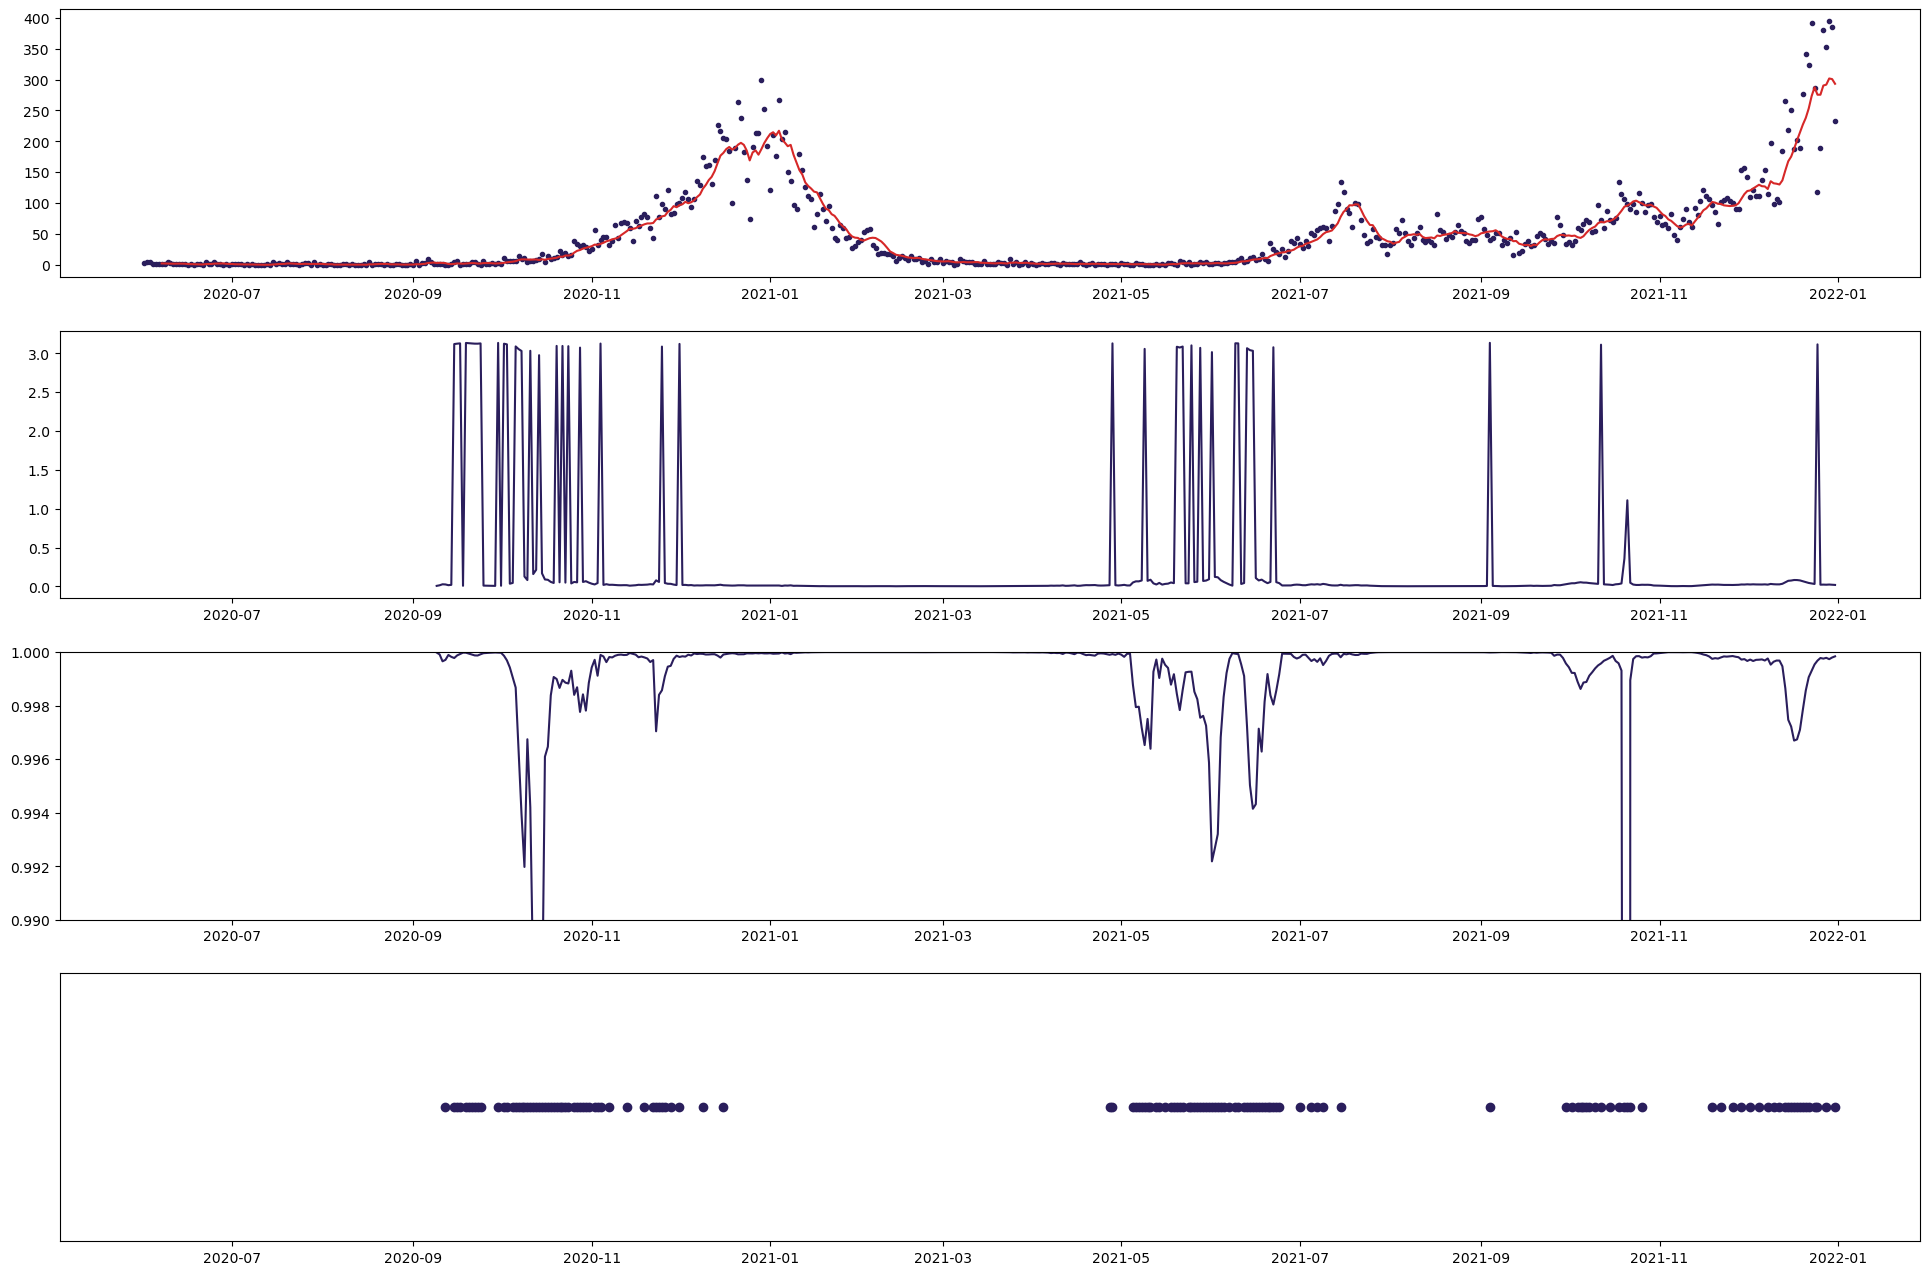

In [14]:
cos_test = cossine_sim(cov_100_evec)
ang = angle_displacement(cov_100_evec)
sig = cusum(ang, noise_std=0.01)

counts = cases_plot[cases_plot['area_name']=='Maidstone']
cols = colormaps.get_cmap('tab10')(np.arange(10))
fig, axs = plt.subplots(nrows=4,ncols=1,figsize=(24,16))
counts['rolling'] = counts['value'].rolling(7).mean()
counts = counts.reset_index()
axs[0].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0].plot(counts['date'],counts['rolling'],color='#D62828')
axs[1].plot(counts['date'],ang,color='#2A1E5C')
axs[2].plot(counts['date'],cos_test,color='#2A1E5C')
axs[2].set_ylim((0.99,1))
axs[3].scatter(counts['date'],sig,color='#2A1E5C')
axs[3].set_ylim(0.9,1.1)
axs[3].set_yticks([])
plt.show()

/tmp/ipykernel_306900/2615005107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['value'].rolling(7).mean()


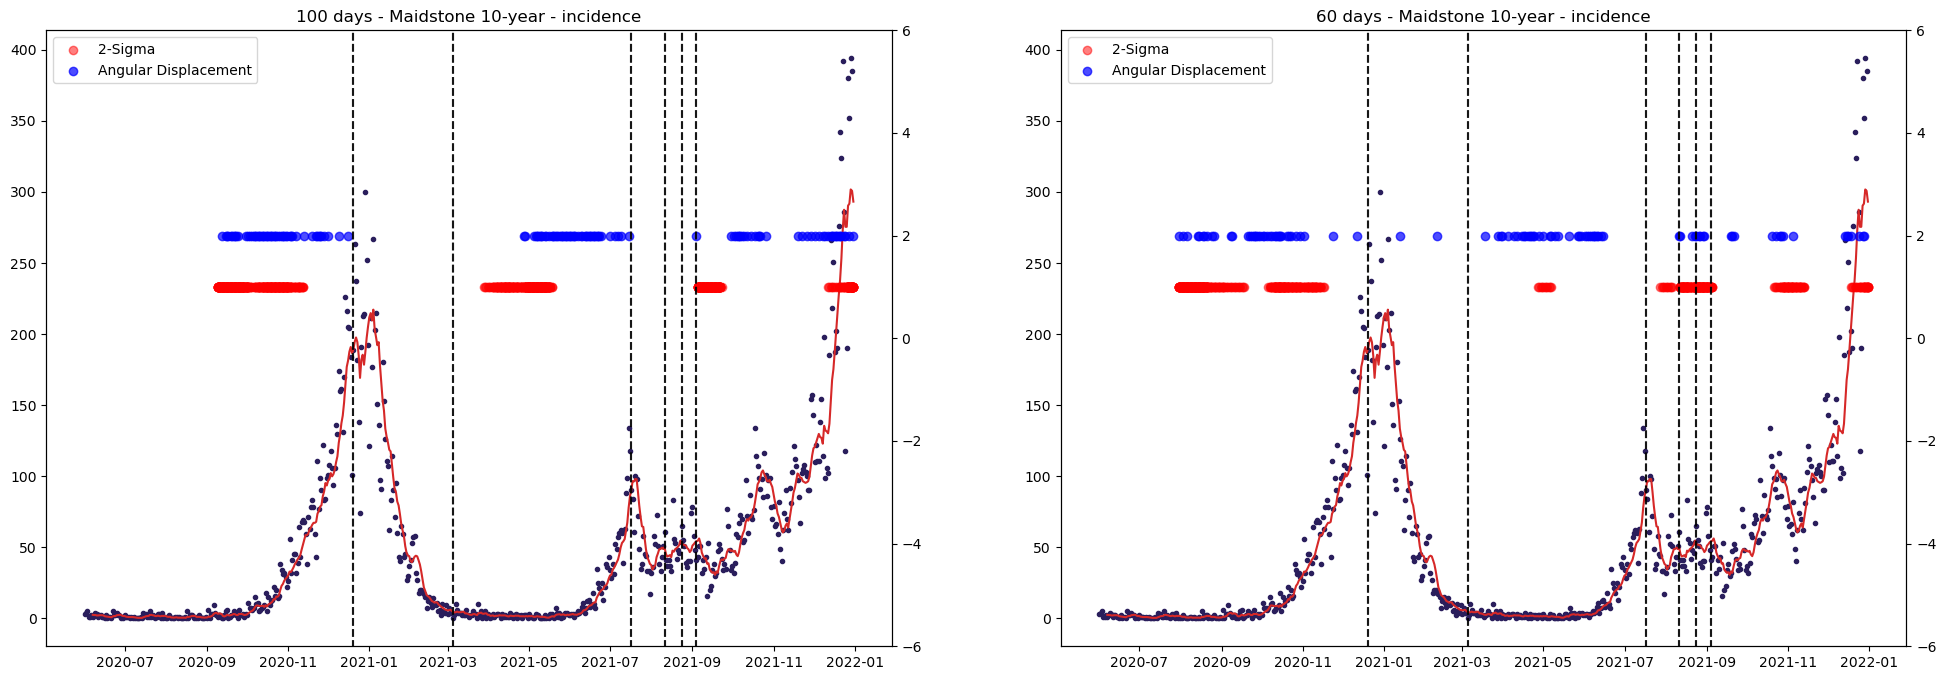

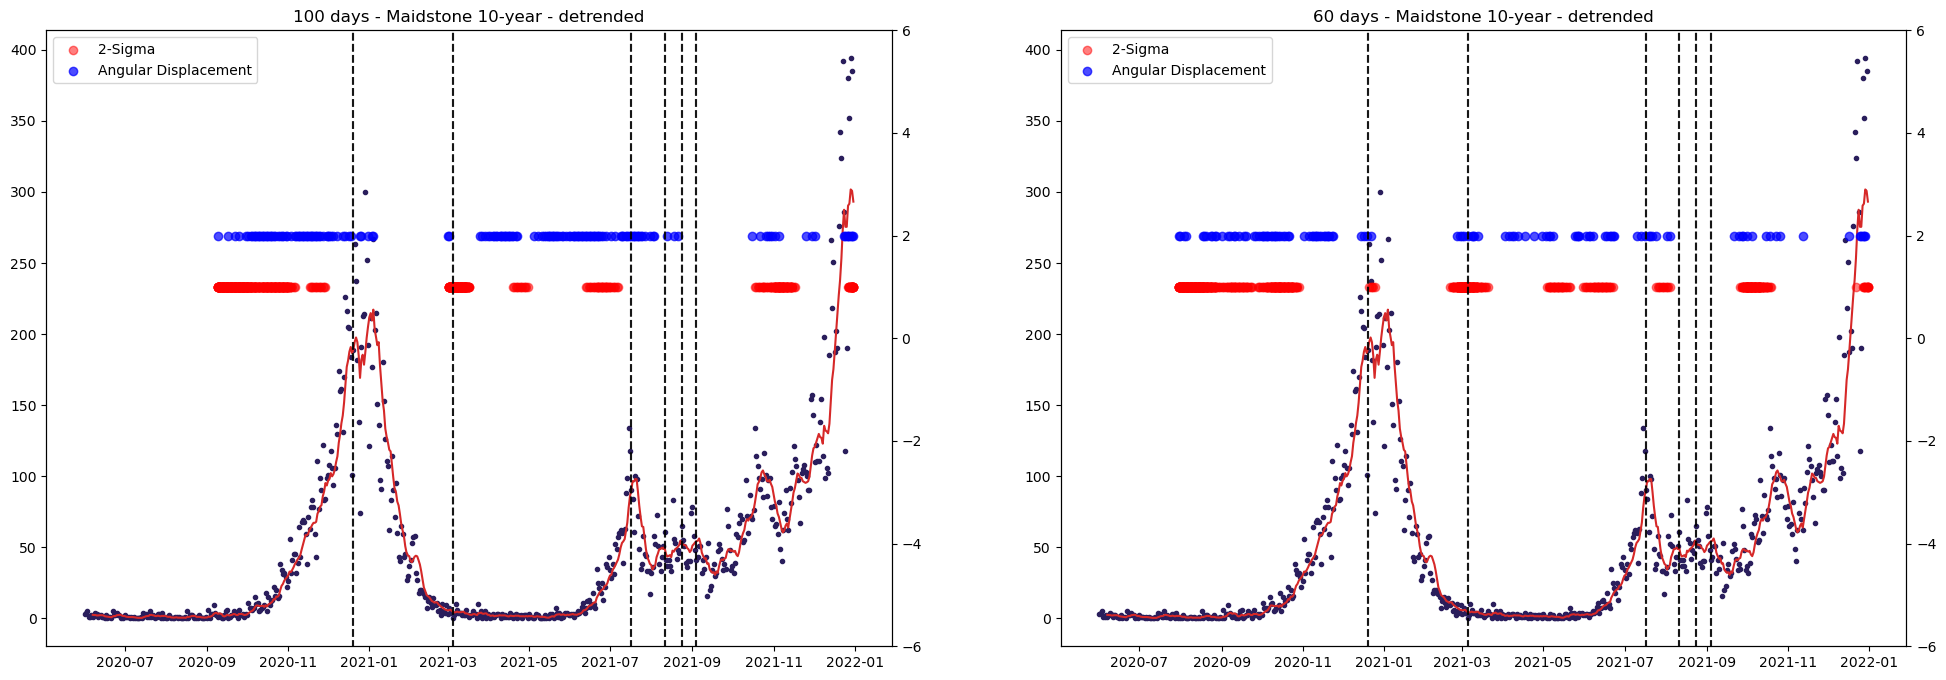

In [47]:
counts = cases_plot[cases_plot['area_name']=='Maidstone']
counts['rolling'] = counts['value'].rolling(7).mean()
counts = counts.reset_index()
plot_results_multivariate(counts,cov_100_evec,cov_60_evec,ltla_transitions['Maidstone'][:-1],31,"Maidstone 10-year - incidence",'10yearincstests')
plot_results_multivariate(counts,cov_100_evec_det,cov_60_evec_det,ltla_transitions['Maidstone'][:-1],31,"Maidstone 10-year - detrended",'10yeardetstests')

## NHS regional

In [26]:
wide_data_incidence_nhs = pd.read_csv('wide_incidence_region.csv',index_col=0)
wide_data_total_nhs = pd.read_csv('wide_total_region.csv',index_col=0)
weekly_counts_total_nhs = pd.read_csv('weekly_total_region.csv')

from copy import deepcopy
national_transitions = np.load('england_transitions.npy',allow_pickle=True)

In [27]:
cases_nhs_full = pd.read_csv('cases_total.csv')
cases_nhs_full['date'] = pd.to_datetime(cases_nhs_full['date'])
cases_nhs_full.set_index('date',inplace=True)
npis = pd.read_csv('ltla_to_nhs.csv')
manual_dat = pd.DataFrame({'ltla20nm': ['Wycombe','South Bucks','Chiltern','Aylesbury Vale','Cornwall and Isles of Scilly', 'Hackney and City of London'], \
                           'region': ['South East', 'South East', 'South East', 'South East', 'South West', 'London']})
npis = pd.concat([npis,manual_dat])
pop_nhs = pd.read_csv('census_estimate.csv')
ltla_pop = pd.read_csv('newCasesPCROnlyBySpecimenDate_ltla_2020.csv')
ltla_pop = ltla_pop[['area_code','area_name']]
ltla_pop.drop_duplicates(inplace=True)
ltla_pop = pd.merge(ltla_pop, npis, left_on='area_name', right_on='ltla20nm').drop(columns='ltla20nm')
ltla_pop = pd.merge(ltla_pop, pop_nhs)
nhs_pop = ltla_pop.groupby('region').sum().drop(columns=['area_code','area_name','Unnamed: 0'])
nhs_pop.reset_index(inplace=True)

cases_nhs = pd.merge(cases_nhs_full.reset_index(), npis, left_on='area_name', right_on='ltla20nm')
cases_nhs.drop(columns=['ltla20nm','area_name','area_code','Unnamed: 0'],inplace=True)
cases_nhs = cases_nhs.groupby(['date','region']).sum().reset_index().set_index('date')

cases_total = cases_nhs.reset_index().drop(columns='region').groupby('date').sum()
cases_total['rolling'] = cases_total.rolling(7).mean()

cases_nhs['rolling'] = np.NaN
cases_nhs = cases_nhs.reset_index()
for r in np.unique(cases_nhs.region.values):
    t = cases_nhs.reset_index()
    t = t[t.region == r].set_index('date')['value'].rolling(7).mean()
    cases_nhs.loc[cases_nhs['region'] == r,'rolling'] = t.values

In [28]:
rolling = wide_data_incidence_nhs.rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_var = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_evec = np.zeros((len(cov.index.get_level_values(0).unique()),7))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_100_total[i] = eigenvalues[dominant_index]
        cov_100_var[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_100_evec[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_100_evec[i] = np.array(7*[0])
        cov_100_total[i] = np.nan
        cov_100_var[i] = np.nan


rolling = wide_data_incidence_nhs.rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_var = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_evec = np.zeros((len(cov.index.get_level_values(0).unique()),7))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_60_total[i] = eigenvalues[dominant_index]
        cov_60_var[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_60_evec[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_60_evec[i] = np.array(7*[0])
        cov_60_total[i] = np.nan
        cov_60_var[i] = np.nan

rolling = wide_data_total_nhs.rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_var_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_evec_det = np.zeros((len(cov.index.get_level_values(0).unique()),7))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_100_total_det[i] = eigenvalues[dominant_index]
        cov_100_var_det[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_100_evec_det[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_100_evec_det[i] = np.array(7*[0])
        cov_100_total_det[i] = np.nan
        cov_100_var_det[i] = np.nan


rolling = wide_data_total_nhs.rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_var_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_evec_det = np.zeros((len(cov.index.get_level_values(0).unique()),7))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_60_total_det[i] = eigenvalues[dominant_index]
        cov_60_var_det[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_60_evec_det[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_60_evec_det[i] = np.array(7*[0])
        cov_60_total_det[i] = np.nan
        cov_60_var_det[i] = np.nan

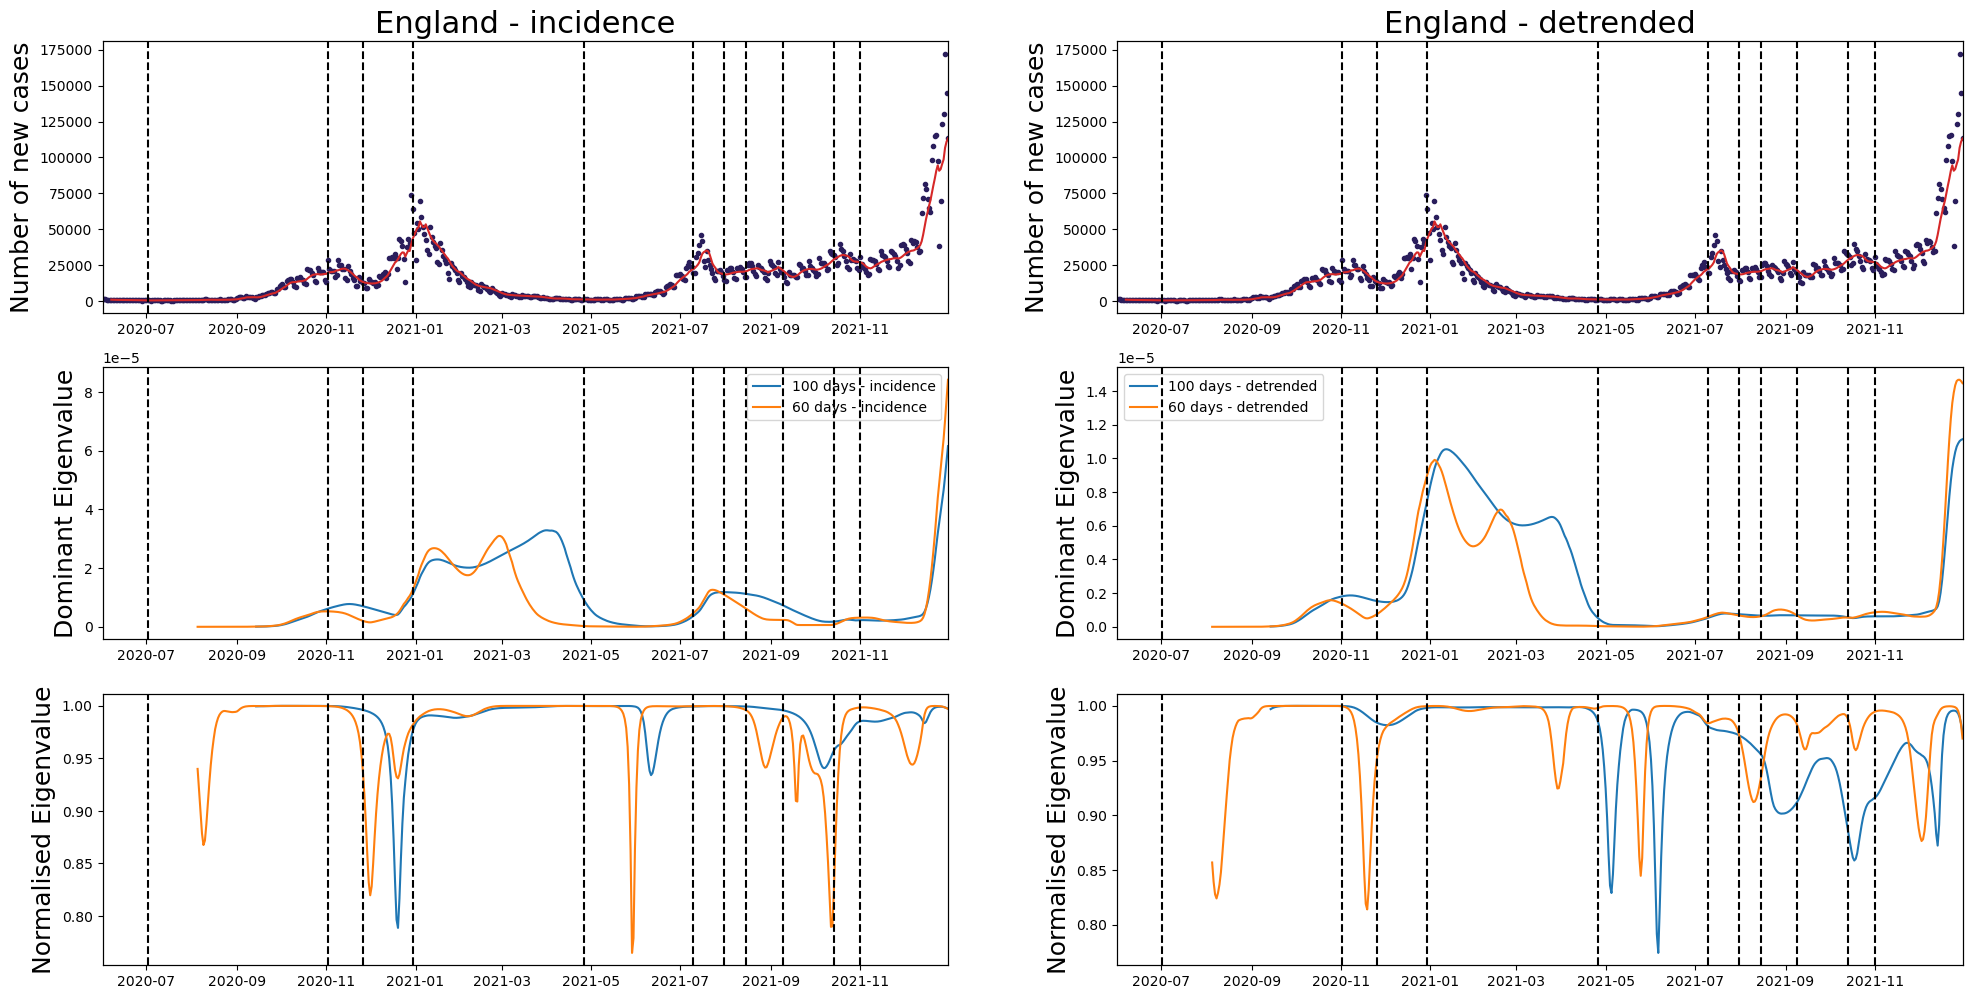

In [169]:
fig, axs = plt.subplots(nrows=3,ncols=2,figsize=(24,12))
counts_nhs = deepcopy(cases_total)
counts_nhs = counts_nhs.reset_index()
axs[0,0].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,0].set_title('England - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[0,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,0].plot(counts_nhs['date'],cov_100_total,label='100 days - incidence')
axs[2,0].plot(counts_nhs['date'],cov_100_var,label='100 days - incidence')
axs[1,0].plot(counts_nhs['date'],cov_60_total,label='60 days - incidence')
axs[2,0].plot(counts_nhs['date'],cov_60_var,label='60 days - incidence')
axs[1,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[2,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,0].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,0].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,0].legend()
axs[0,1].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,1].set_title('England - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[0,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,1].plot(counts_nhs['date'],cov_100_total_det,label='100 days - detrended')
axs[2,1].plot(counts_nhs['date'],cov_100_var_det,label='100 days - detrended')
axs[1,1].plot(counts_nhs['date'],cov_60_total_det,label='60 days - detrended')
axs[2,1].plot(counts_nhs['date'],cov_60_var_det,label='60 days - detrended')
axs[1,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[2,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,1].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,1].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,1].legend()

for i in range(3):
    for j in range(2):
        axs[i,j].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=national_transitions[:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])

plt.savefig('Figures/NHSevalues.pdf',dpi=2400,bbox_inches='tight')
plt.show()

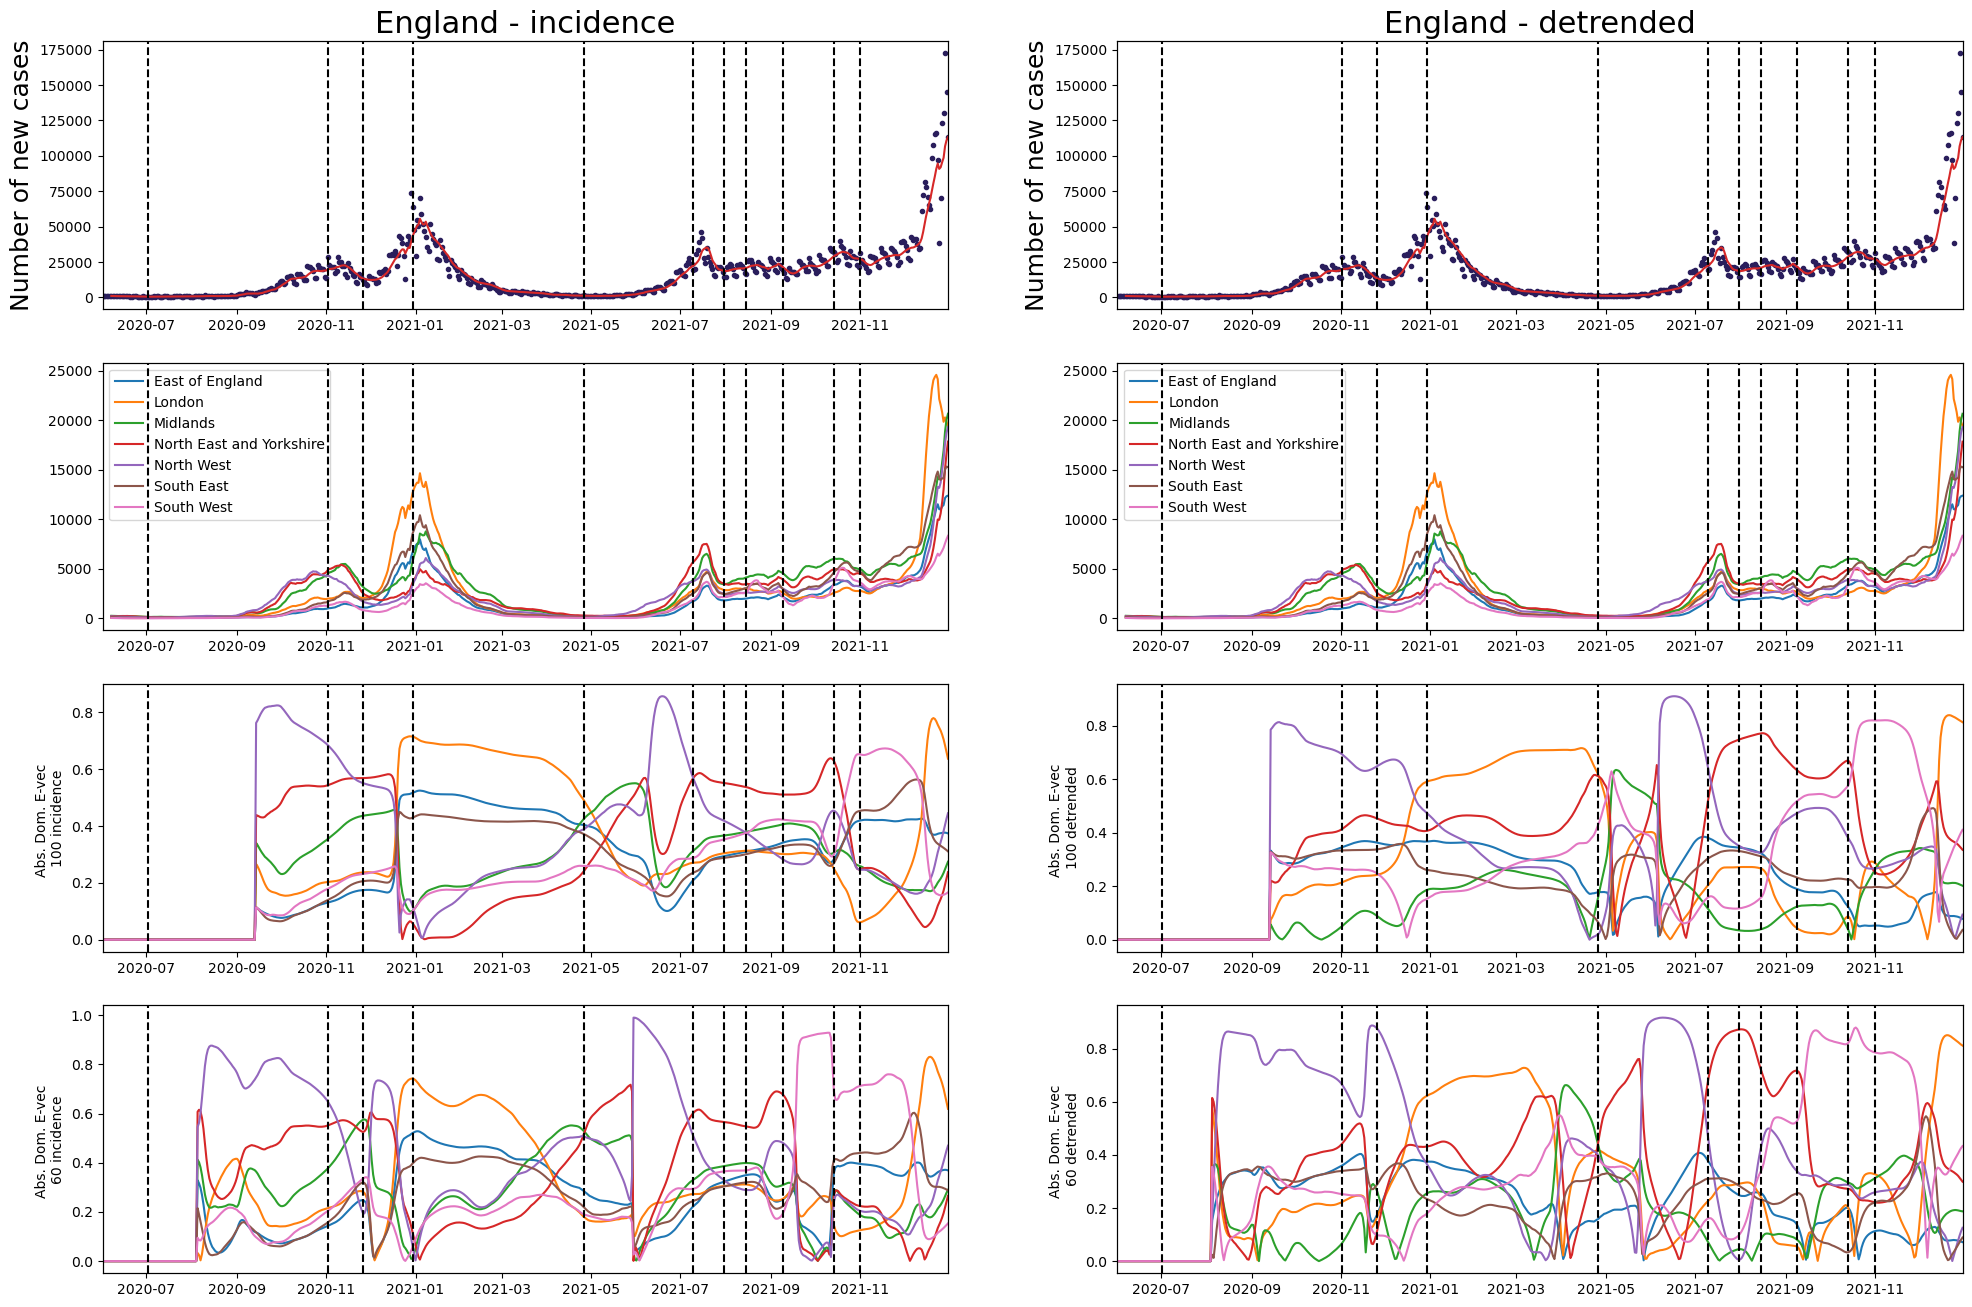

In [170]:
labs = ['East of England','London',"Midlands","North East and Yorkshire","North West","South East","South West"]
fig, axs = plt.subplots(nrows=4,ncols=2,figsize=(24,16))
counts_nhs = deepcopy(cases_total)
counts_nhs = counts_nhs.reset_index()
axs[0,0].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,0].set_title('England - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[0,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
for i in range(len(labs)):
    t = cases_nhs.loc[cases_nhs['region'] == labs[i], 'rolling']
    axs[1,0].plot(counts_nhs['date'], t,label=labs[i])
for i in range(len(cov_100_evec[0])):
    axs[2,0].plot(counts_nhs['date'],np.abs(cov_100_evec[:,i]),label=labs[i])
axs[2,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[2,0].set_ylabel('Abs. Dom. E-vec \n100 incidence')
for i in range(len(cov_60_evec[0])):
    axs[3,0].plot(counts_nhs['date'],np.abs(cov_60_evec[:,i]))
axs[3,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[3,0].set_ylabel('Abs. Dom. E-vec \n60 incidence')
axs[1,0].legend()

axs[0,1].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,1].set_title('England - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[0,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
for i in range(len(labs)):
    t = cases_nhs.loc[cases_nhs['region'] == labs[i], 'rolling']
    axs[1,1].plot(counts_nhs['date'], t,label=labs[i])
for i in range(len(cov_100_evec_det[0])):
    axs[2,1].plot(counts_nhs['date'],np.abs(cov_100_evec_det[:,i]),label=labs[i])
axs[2,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[2,1].set_ylabel('Abs. Dom. E-vec \n100 detrended')
for i in range(len(cov_60_evec_det[0])):
    axs[3,1].plot(counts_nhs['date'],np.abs(cov_60_evec_det[:,i]))
axs[3,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[3,1].set_ylabel('Abs. Dom. E-vec \n60 detrended')
axs[1,1].legend()
for i in range(4):
    for j in range(2):
        axs[i,j].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=national_transitions[:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
plt.savefig('Figures/NHSevectors.pdf')
plt.show()

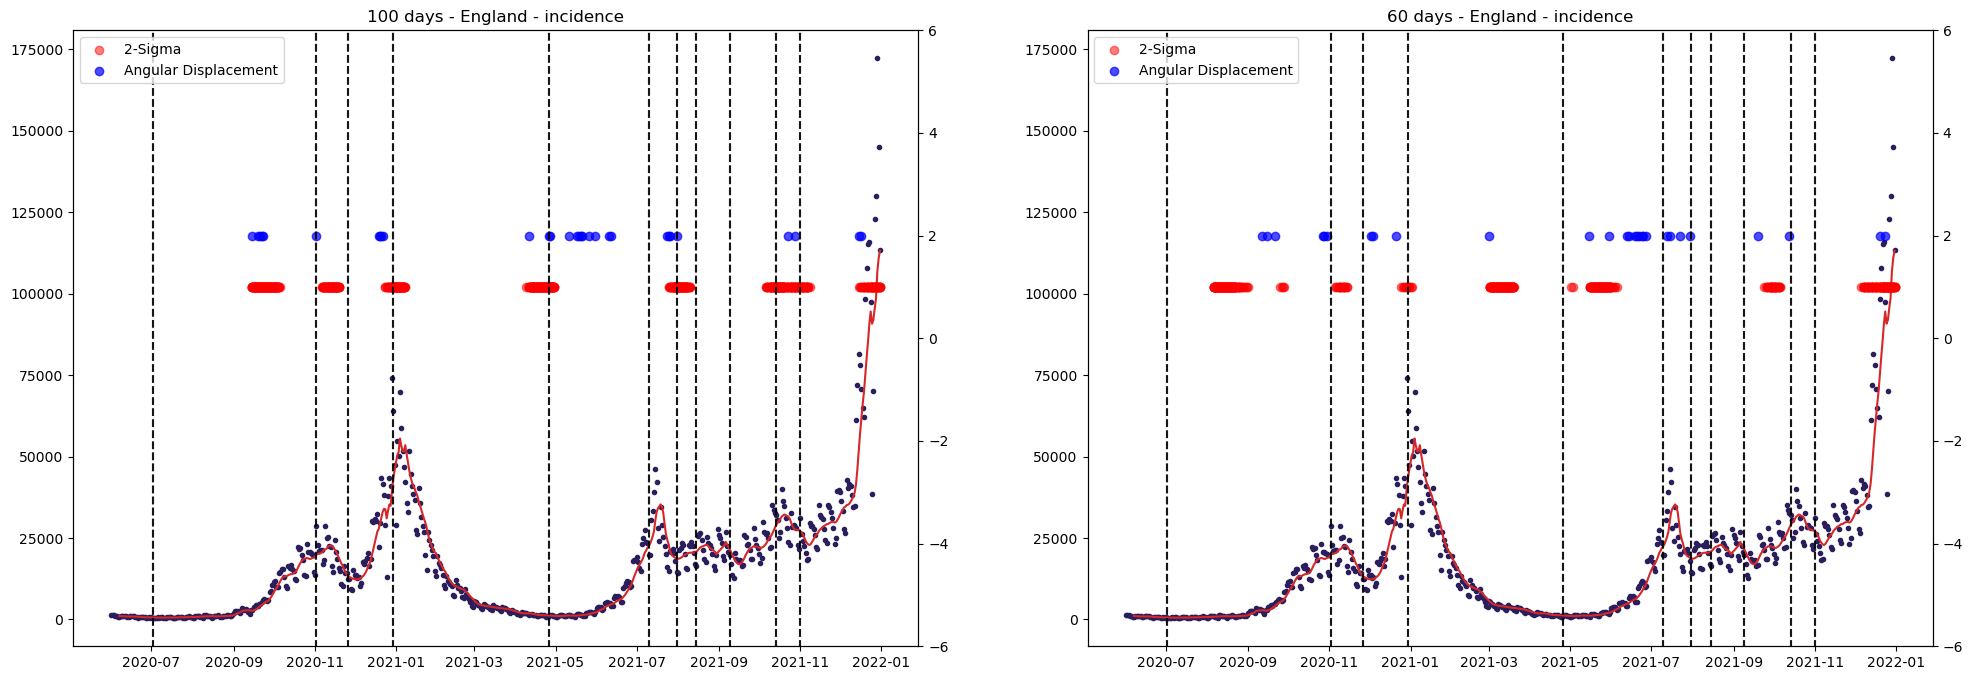

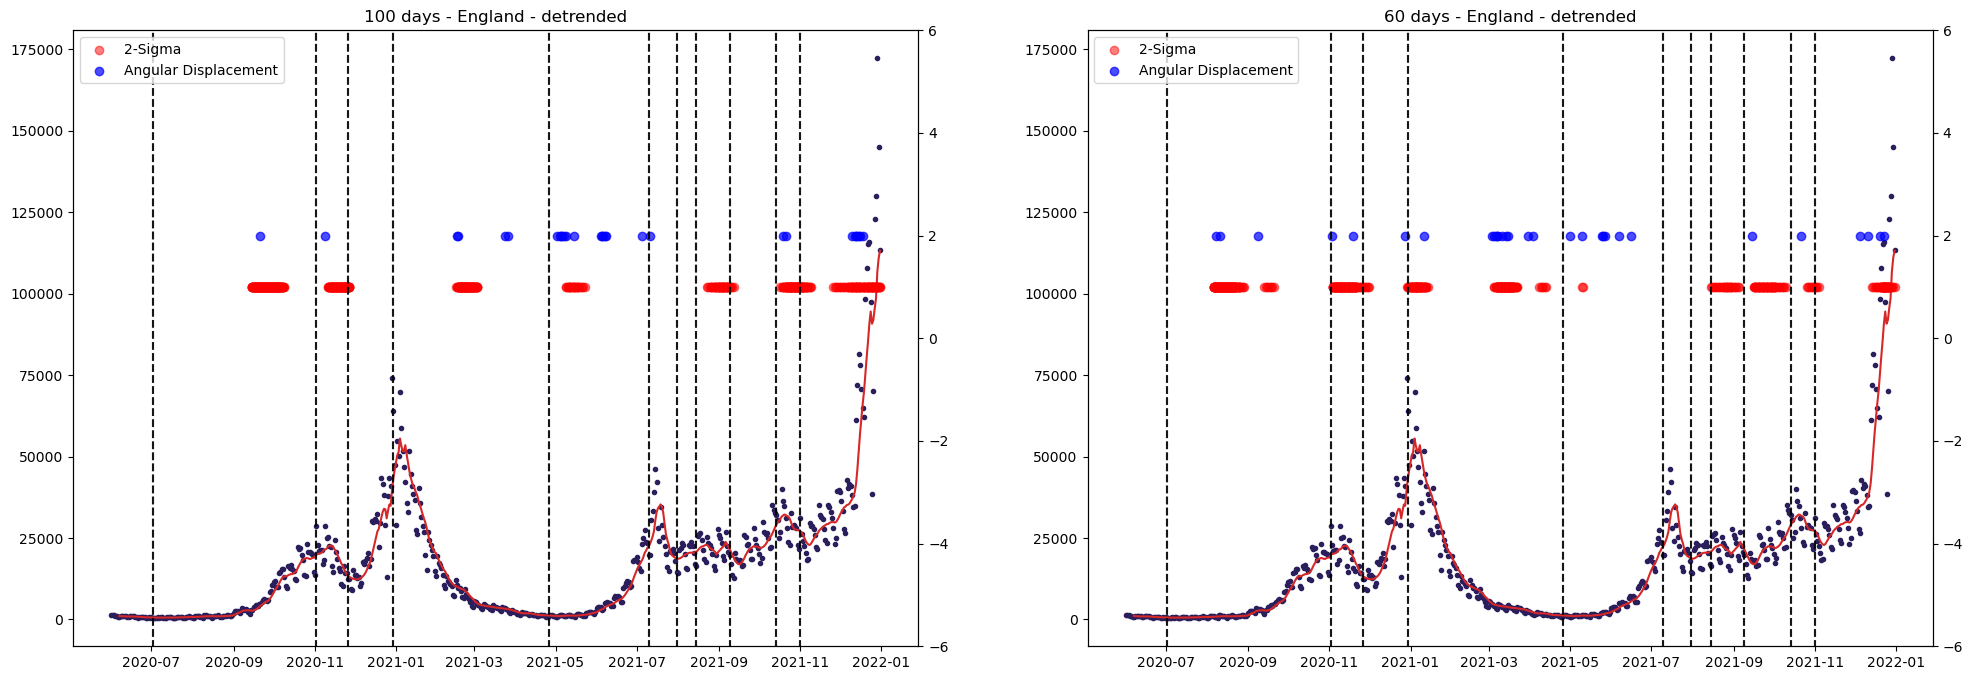

In [31]:
from copy import deepcopy
counts_nhs = deepcopy(cases_total)
counts_nhs = counts_nhs.reset_index()
plot_results_multivariate(counts_nhs,cov_100_evec,cov_60_evec,national_transitions[:-1],31,"England - incidence",'regionalincstests',(0.03,0.07))
plot_results_multivariate(counts_nhs,cov_100_evec_det,cov_60_evec_det,national_transitions[:-1],31,"England - detrended",'regionaldetstests',(0.03,0.07))

## NHS age-structured

In [32]:
wide_data_total = pd.read_csv('regional_wide_total_10year_full.csv',header=[0,1], index_col=0)
wide_data_incidence = pd.read_csv('regional_wide_incidence_10year_full.csv',header=[0,1], index_col=0)
cases_plot = pd.read_csv('cases_region.csv')
cases_plot['date'] = pd.to_datetime(cases_plot['date'])
cases_plot.set_index('date',inplace=True)
counts = cases_plot[cases_plot['region']=='South East']

In [33]:
import pickle        
with open('nhs_transitions.pkl', 'rb') as f:
    nhs_transitions = pickle.load(f)

In [34]:
rolling = wide_data_incidence['South East'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_var = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_evec = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_100_total[i] = eigenvalues[dominant_index]
        cov_100_var[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_100_evec[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_100_evec[i] = np.array(10*[0])
        cov_100_total[i] = np.nan
        cov_100_var[i] = np.nan


rolling = wide_data_incidence['South East'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_var = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_evec = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_60_total[i] = eigenvalues[dominant_index]
        cov_60_var[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_60_evec[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_60_evec[i] = np.array(10*[0])
        cov_60_total[i] = np.nan
        cov_60_var[i] = np.nan

rolling = wide_data_total['South East'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_var_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_100_evec_det = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_100_total_det[i] = eigenvalues[dominant_index]
        cov_100_var_det[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_100_evec_det[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_100_evec_det[i] = np.array(10*[0])
        cov_100_total_det[i] = np.nan
        cov_100_var_det[i] = np.nan

rolling = wide_data_total['South East'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_var_det = np.zeros(len(cov.index.get_level_values(0).unique()))
cov_60_evec_det = np.zeros((len(cov.index.get_level_values(0).unique()),10))

for i, date in enumerate(cov.index.get_level_values(0).unique()):
    if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
        eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
        dominant_index = np.argmax(eigenvalues)
        dominant_eigenvalue = eigenvalues[dominant_index]
        dominant_eigenvector = eigenvectors[:, dominant_index]
        cov_60_total_det[i] = eigenvalues[dominant_index]
        cov_60_var_det[i] = eigenvalues[dominant_index]/np.linalg.norm(eigenvalues)
        cov_60_evec_det[i, :] = eigenvectors[:, dominant_index].flatten()
    else:
        cov_60_evec_det[i] = np.array(10*[0])
        cov_60_total_det[i] = np.nan
        cov_60_var_det[i] = np.nan

/tmp/ipykernel_306900/2999340262.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['cases'].rolling(7).mean()


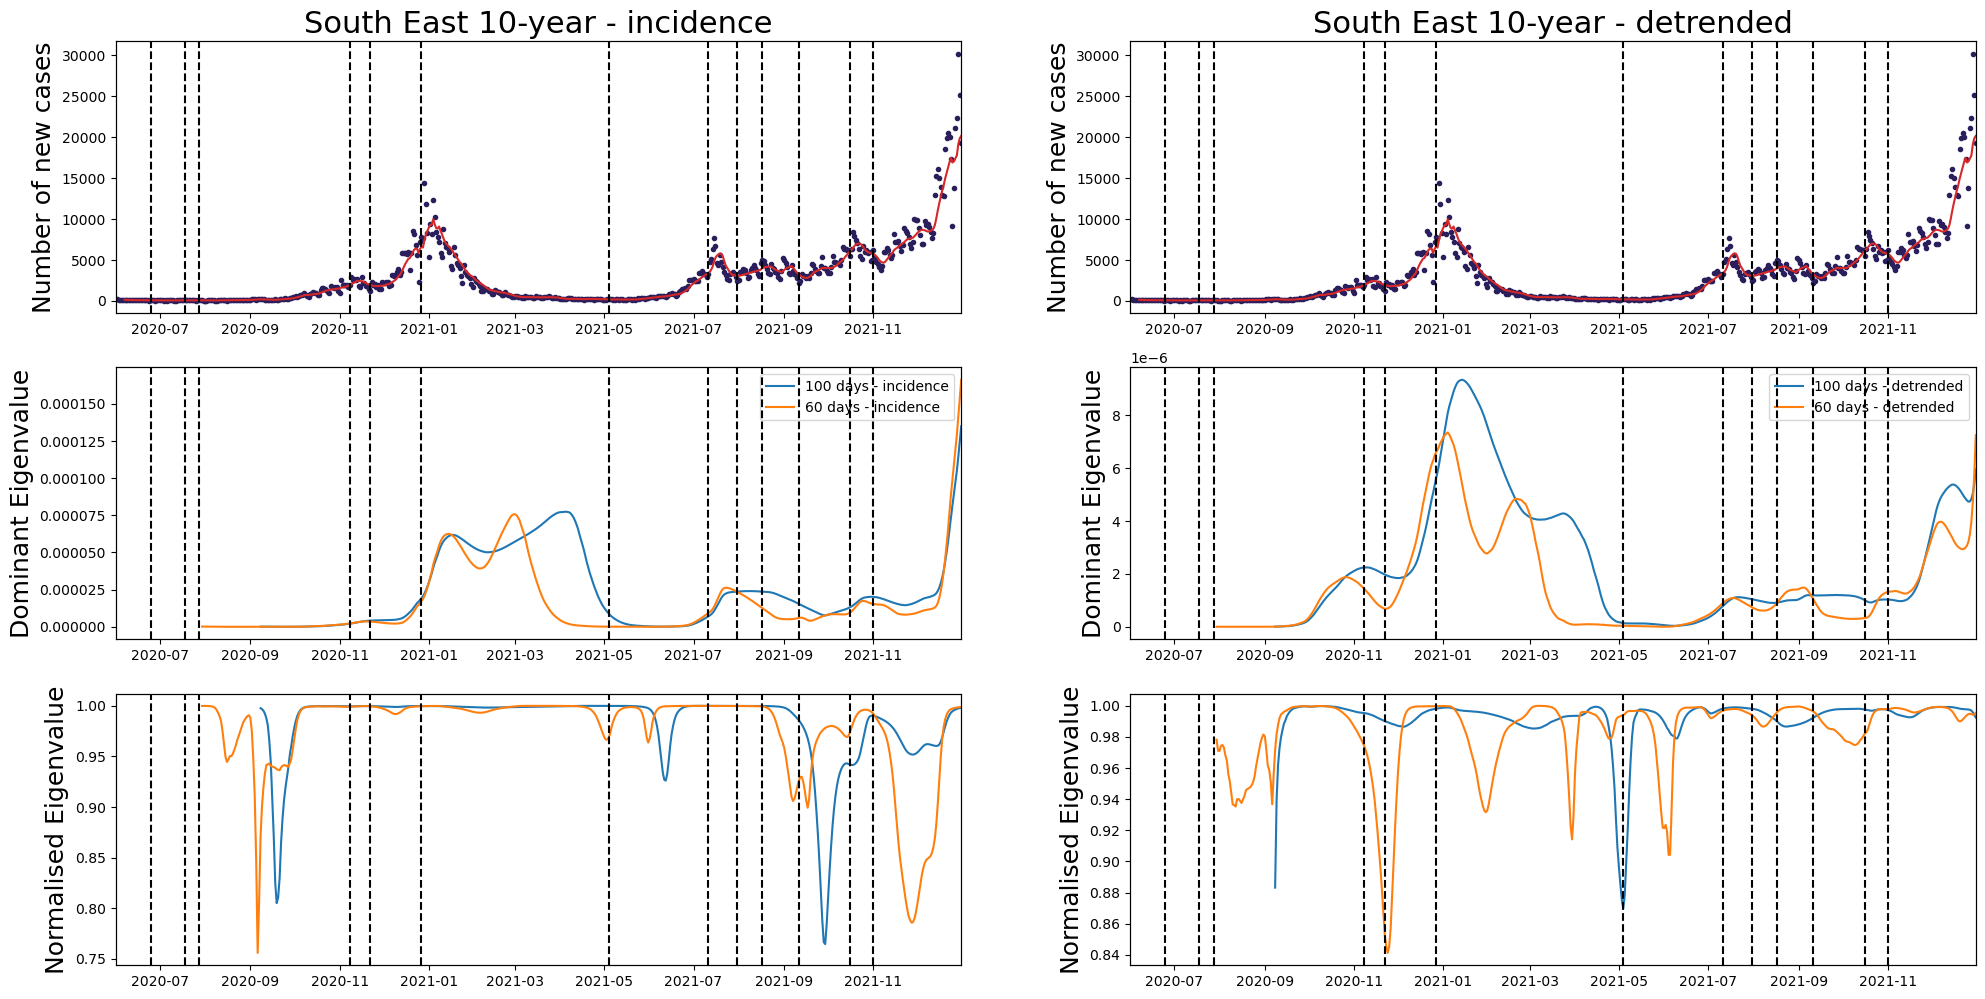

In [35]:
counts = cases_plot[cases_plot['region']=='South East']
fig, axs = plt.subplots(nrows=3,ncols=2,figsize=(24,12))
counts['rolling'] = counts['cases'].rolling(7).mean()
counts = counts.reset_index()
axs[0,0].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
# axs[0,0].set_ylim((0,14000))
axs[0,0].set_title('South East 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[1,0].plot(counts['date'],cov_100_total,label='100 days - incidence')
axs[2,0].plot(counts['date'],cov_100_var,label='100 days - incidence')
axs[1,0].plot(counts['date'],cov_60_total,label='60 days - incidence')
axs[2,0].plot(counts['date'],cov_60_var,label='60 days - incidence')
axs[1,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,0].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,0].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,0].legend()

axs[0,1].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
# axs[0,1].set_ylim((0,14000))
axs[0,1].set_title('South East 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[1,1].plot(counts['date'],cov_100_total_det,label='100 days - detrended')
axs[2,1].plot(counts['date'],cov_100_var_det,label='100 days - detrended')
axs[1,1].plot(counts['date'],cov_60_total_det,label='60 days - detrended')
axs[2,1].plot(counts['date'],cov_60_var_det,label='60 days - detrended')
axs[1,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,1].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,1].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,1].legend()
for i in range(3):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=nhs_transitions['South East'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
plt.savefig("Figures/10yearevaluesregion.pdf",dpi=2400,bbox_inches='tight')
plt.show()

/tmp/ipykernel_306900/1153771823.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['cases'].rolling(7).mean()


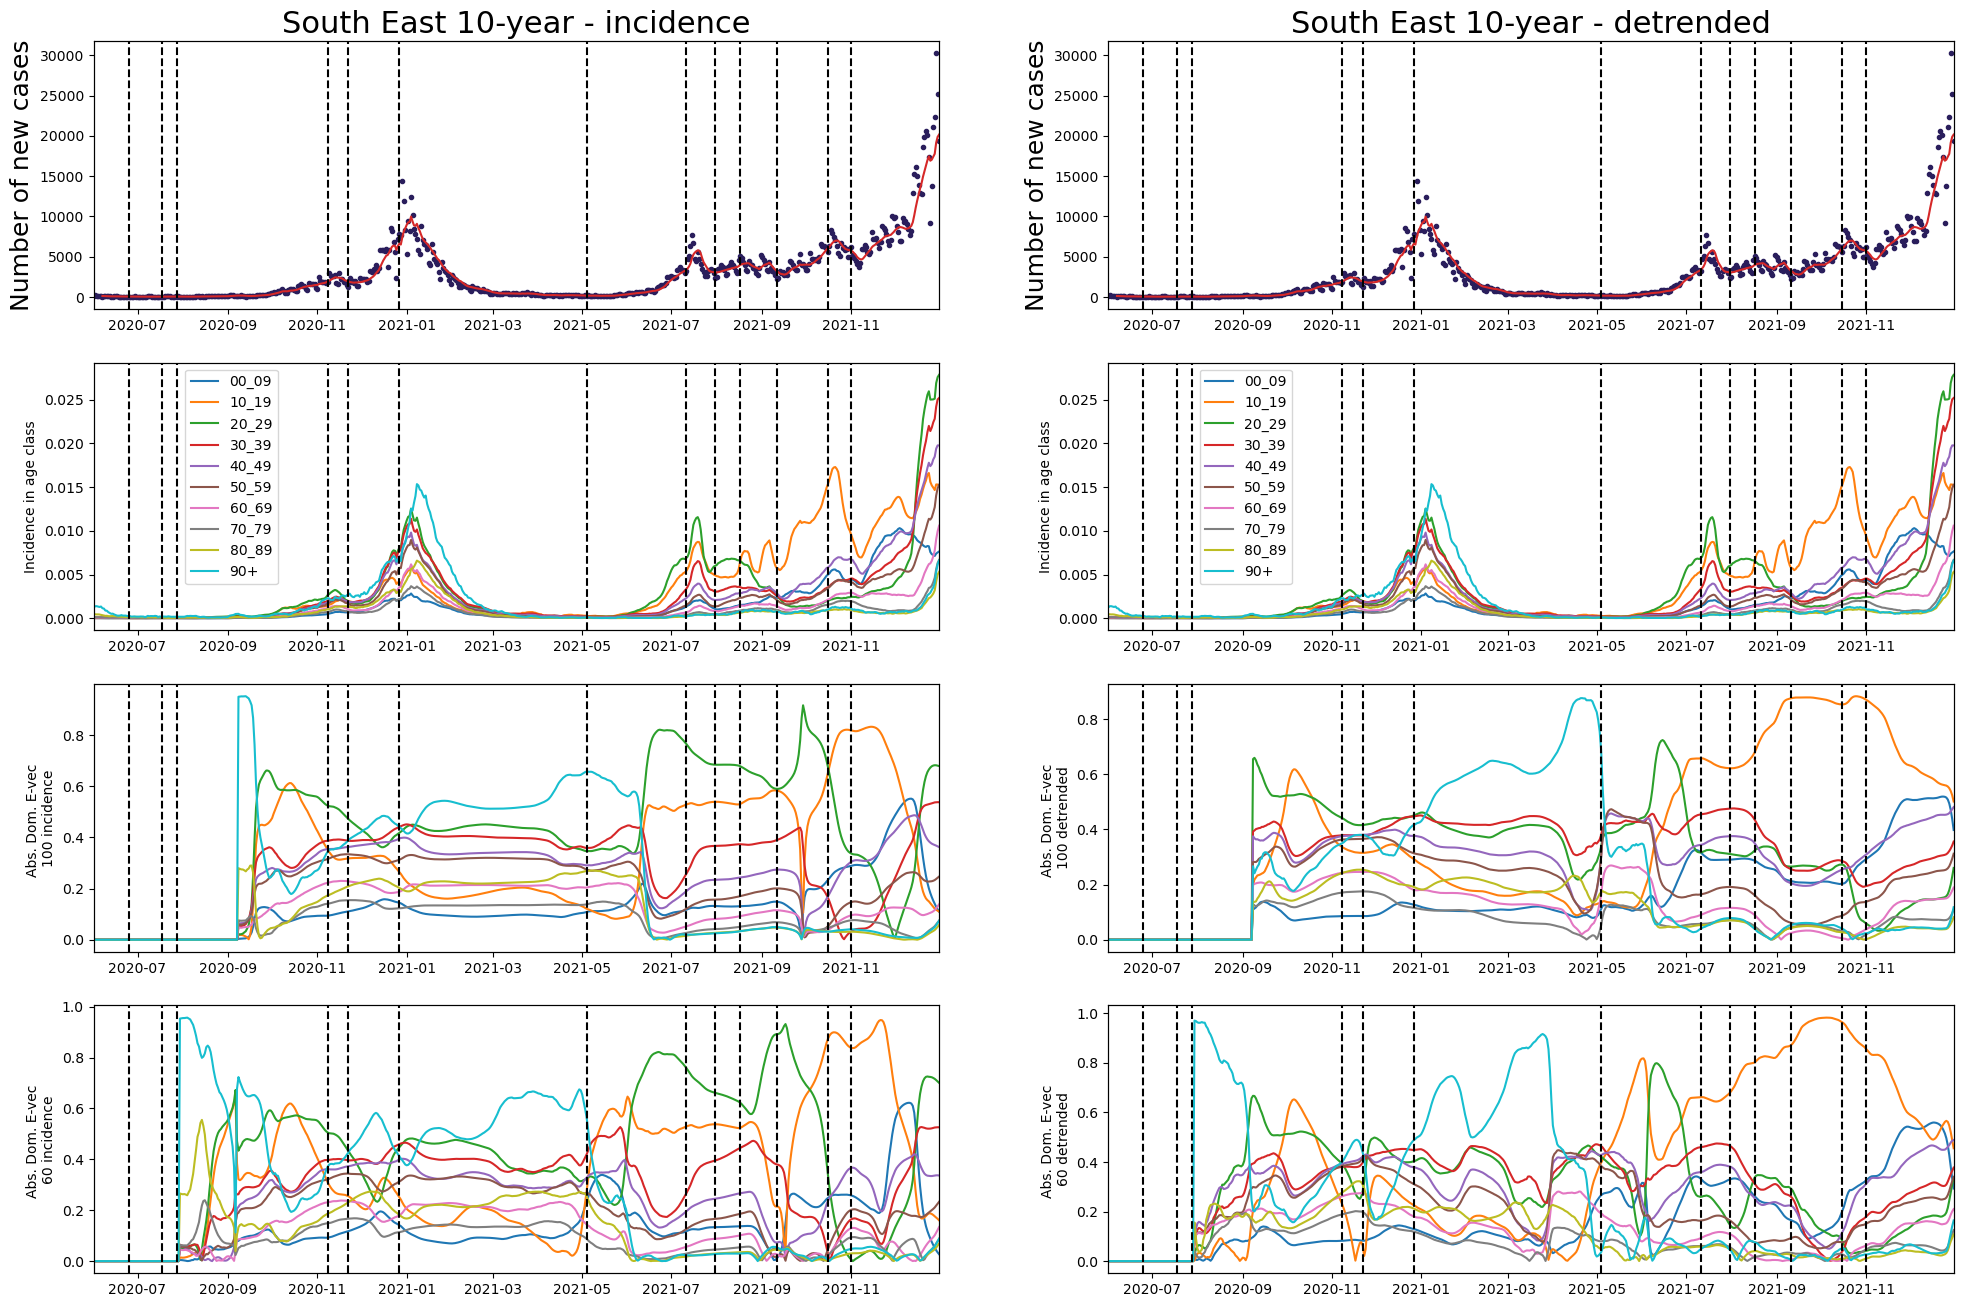

In [36]:
labs = ['00_09', '10_19', '20_29', '30_39', '40_49', '50_59', '60_69', '70_79','80_89', '90+']
counts = cases_plot[cases_plot['region']=='South East']
cols = colormaps.get_cmap('tab10')(np.arange(10))
fig, axs = plt.subplots(nrows=4,ncols=2,figsize=(24,16))
counts['rolling'] = counts['cases'].rolling(7).mean()
counts = counts.reset_index()
axs[0,0].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
# axs[0,0].set_ylim((0,14000))
axs[0,0].set_title('South East 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
for i in range(len(labs)):
    t = wide_data_incidence['South East'][labs[i]]
    axs[1,0].plot(counts['date'],t,label=labs[i])
axs[1,0].set_ylabel('Incidence in age class')
for i in range(len(cov_100_evec[0])):
    axs[2,0].plot(counts['date'],np.abs(cov_100_evec[:,i]))
axs[2,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,0].set_ylabel('Abs. Dom. E-vec \n100 incidence')
for i in range(len(cov_60_evec[0])):
    axs[3,0].plot(counts['date'],np.abs(cov_60_evec[:,i]))
axs[3,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[3,0].set_ylabel('Abs. Dom. E-vec \n60 incidence')
axs[1,0].legend(loc='upper left', bbox_to_anchor=(0.1, 1))

axs[0,1].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
# axs[0,1].set_ylim((0,14000))
axs[0,1].set_title('South East 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
for i in range(len(labs)):
    t = wide_data_incidence['South East'][labs[i]]
    axs[1,1].plot(counts['date'],t,label=labs[i])
axs[1,1].set_ylabel('Incidence in age class')
for i in range(len(cov_100_evec_det[0])):
    axs[2,1].plot(counts['date'],np.abs(cov_100_evec_det[:,i]))
axs[2,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,1].set_ylabel('Abs. Dom. E-vec \n100 detrended')
for i in range(len(cov_60_evec_det[0])):
    axs[3,1].plot(counts['date'],np.abs(cov_60_evec_det[:,i]))
axs[3,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[3,1].set_ylabel('Abs. Dom. E-vec \n60 detrended')
axs[1,1].legend(loc='upper left', bbox_to_anchor=(0.1, 1))
for i in range(4):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=nhs_transitions['South East'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
plt.savefig("Figures/10yearevectorsregion.pdf",dpi=2400,bbox_inches='tight')
plt.show()

/tmp/ipykernel_306900/1134915315.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['value'] = counts['cases']
/tmp/ipykernel_306900/1134915315.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['value'].rolling(7).mean()


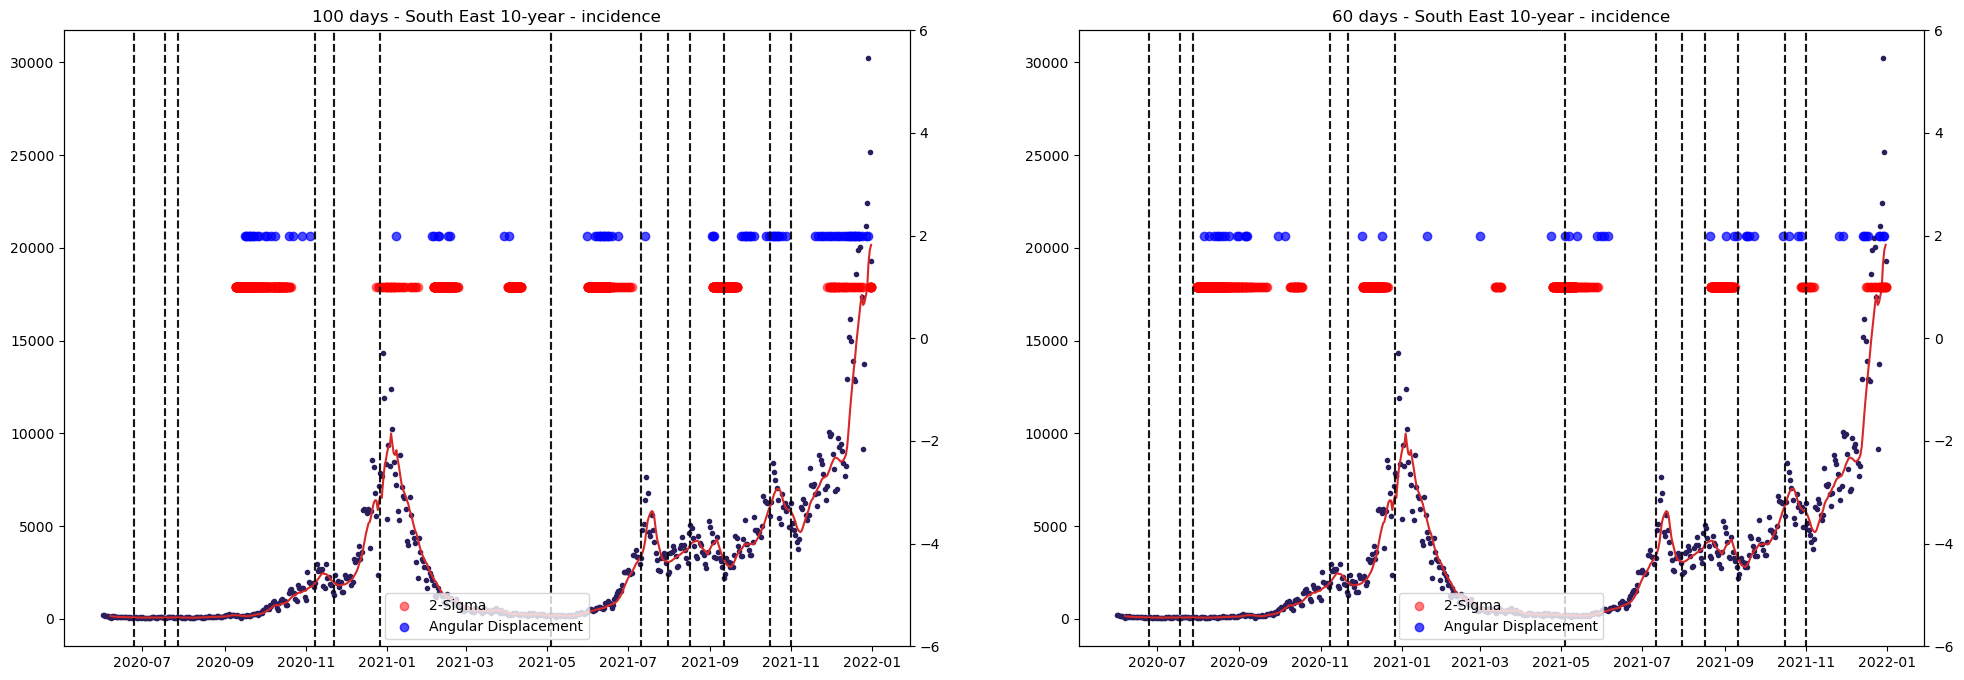

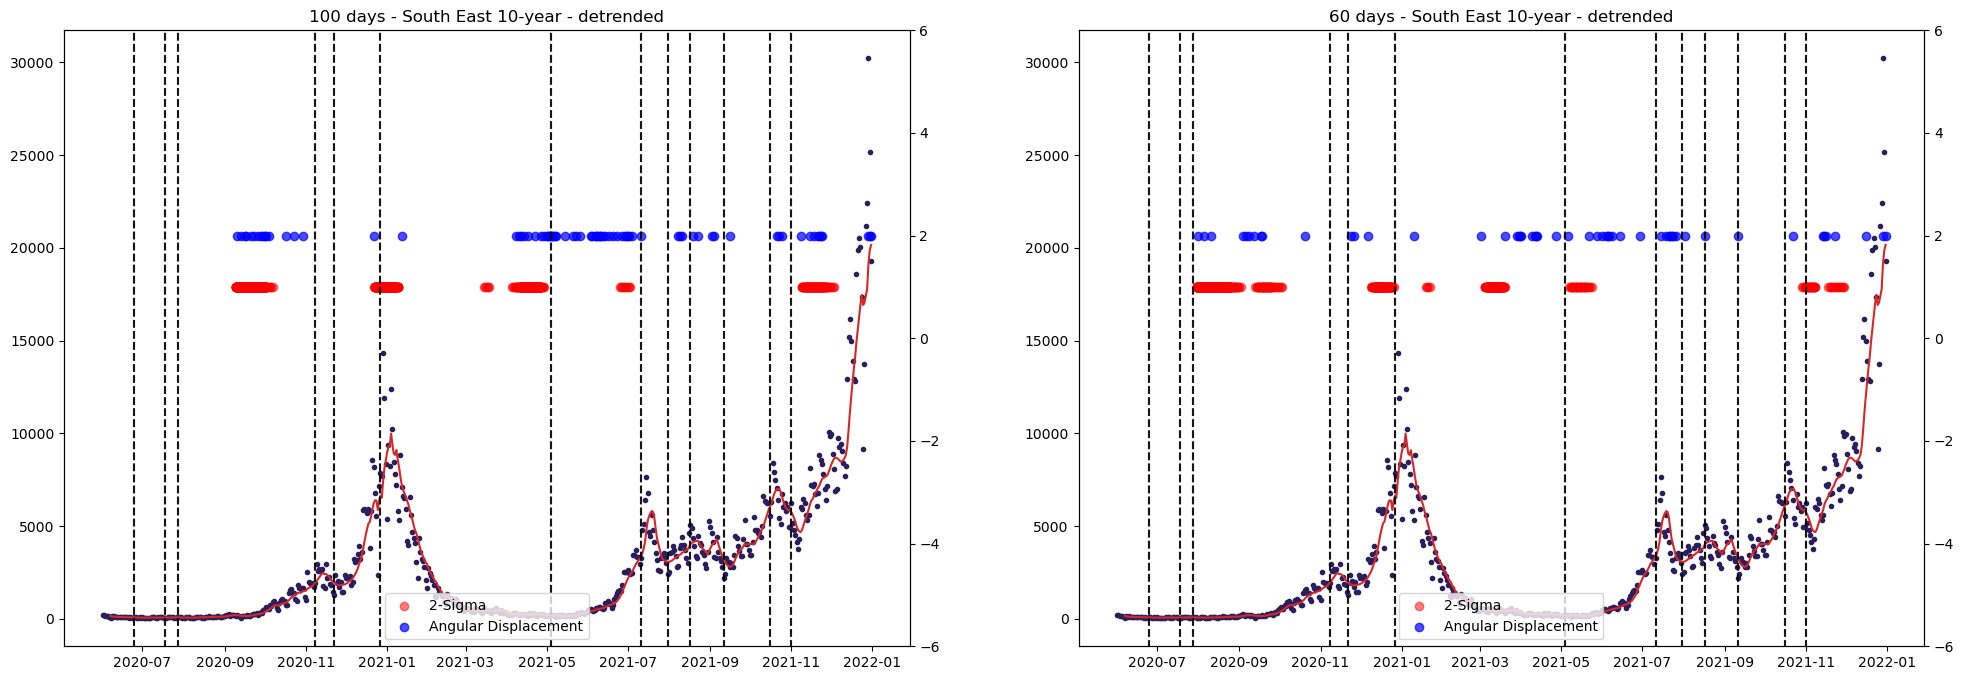

In [41]:
counts = cases_plot[cases_plot['region']=='South East']
counts['value'] = counts['cases']
counts['rolling'] = counts['value'].rolling(7).mean()
counts = counts.reset_index()
plot_results_multivariate(counts,cov_100_evec,cov_60_evec,nhs_transitions['South East'][:-1],31,"South East 10-year - incidence",'10yearincstestsregion')
plot_results_multivariate(counts,cov_100_evec_det,cov_60_evec_det,nhs_transitions['South East'][:-1],31,"South East 10-year - detrended",'10yeardetstestsregion')